In [1]:
from transformers import PreTrainedModel
from transformers.modeling_outputs import SequenceClassifierOutput
import torch.nn as nn
import torch.nn.functional as F
from transformers import PretrainedConfig
# from transformers import ASTConfig
from transformers import ASTModel, ASTConfig
ast_base = ASTModel.from_pretrained("MIT/ast-finetuned-audioset-10-10-0.4593")

c:\Users\Marina\genres\beat_venv_new\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\Marina\genres\beat_venv_new\Lib\site-packages\huggingface_hub\file_download.py:943: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


In [2]:
import numpy as np

data_fma = np.load(r"data\fma_test_unsorted.npz")
lst = data_fma.files
genres = [file.split("___")[0] for file in lst]
genres[:10]

['Electronic',
 'Electronic',
 'Electronic',
 'Electronic',
 'Electronic',
 'Electronic',
 'Electronic',
 'Electronic',
 'Electronic',
 'Electronic']

In [3]:
class ASTGenreConfig(ASTConfig):
    model_type= "ast-genre_classification"
    def __init__(self, **kwargs):   # **kwargs: arbitrary number of key words arguments
        super().__init__(**kwargs)
        self.num_labels =kwargs.get("num_labels", 13)
        self.dropouts = kwargs.get("dropouts", 0.2)
        self.learning_rate = kwargs.get("learning_rate",3e-5 )
        self.freeze_layers = kwargs.get("freeze_layers", None)
        self.dropout_top = kwargs.get("dropout_top", 0)


class ASTForGenreClassification(PreTrainedModel):
    config_class = ASTGenreConfig

    def __init__(self, config, ast_model=ast_base):
        super().__init__(config)
        self.ast = ast_model
        self.dropout = nn.Dropout(config.dropout_top)
        self.activation_fn = self.get_activation(config.activation_fn)
        self.freeze_layers = config.freeze_layers
        self.classifier = nn.Linear(768, config.num_labels)
        self.normalisation = self.get_normalisation(config.normalisation, 768)
        if self.freeze_layers:
            print(f"freezing {self.freeze_layers} layers")
            for i, layer in enumerate(self.ast.encoder.layer):
                if i < self.freeze_layers:
                    for param in layer.parameters():
                        param.requires_grad = False
        

    def get_activation(self, activation_fn) -> nn.Module:
        acrivation_mapping = {
        "relu":  nn.ReLU(),
        "gelu":  nn.GELU(),
        "none":  nn.Identity(),
    }
        return acrivation_mapping.get(activation_fn)
    def get_normalisation(self, norm_type, dim) -> nn.Module:
        norm_mapping = {
        "layer": lambda d: nn.LayerNorm(d),
        "none": lambda d: nn.Identity(),
    }
        return norm_mapping.get(norm_type, lambda d: nn.Identity())(dim)
    def forward(self, input_values, labels=None):
        x = self.ast.embeddings(input_values)
        x = self.ast.encoder(x).last_hidden_state
        x = self.normalisation(x)
        x = x.mean(dim=1)
        x = self.dropout(x)
        x = self.activation_fn(x)
        logits = self.classifier(x)
        assert labels.max() < logits.shape[1], f"Invalid label {labels.max()} for {logits.shape[1]} classes"
        loss = None
        if labels is not None:
            loss = F.cross_entropy(logits, labels, label_smoothing=0.1)
        return SequenceClassifierOutput(loss=loss, logits=logits)

In [75]:
import os
os.environ["HF_TOKEN"] =   ""
model = ASTForGenreClassification.from_pretrained("PolinaKozarovytska/ast_merge", revision= "83580f85ab0b522005a69c7b1bb7f31e0d891589")
model.eval()  # set to evaluation mode


c:\Users\Marina\genres\beat_venv_new\Lib\site-packages\huggingface_hub\file_download.py:943: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


freezing 4 layers


ASTForGenreClassification(
  (ast): ASTModel(
    (embeddings): ASTEmbeddings(
      (patch_embeddings): ASTPatchEmbeddings(
        (projection): Conv2d(1, 768, kernel_size=(16, 16), stride=(10, 10))
      )
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (encoder): ASTEncoder(
      (layer): ModuleList(
        (0-11): 12 x ASTLayer(
          (attention): ASTAttention(
            (attention): ASTSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
            (output): ASTSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
          )
          (intermediate): ASTIntermediate(
            (dense): Linear(in_features=7

In [76]:
from torchinfo import summary
summary(model)

Layer (type:depth-idx)                                  Param #
ASTForGenreClassification                               --
├─ASTModel: 1-1                                         --
│    └─ASTEmbeddings: 2-1                               933,888
│    │    └─ASTPatchEmbeddings: 3-1                     197,376
│    │    └─Dropout: 3-2                                --
│    └─ASTEncoder: 2-2                                  --
│    │    └─ModuleList: 3-3                             85,054,464
│    └─LayerNorm: 2-3                                   1,536
├─Dropout: 1-2                                          --
├─Identity: 1-3                                         --
├─Linear: 1-4                                           9,997
├─Identity: 1-5                                         --
Total params: 86,197,261
Trainable params: 57,845,773
Non-trainable params: 28,351,488

In [77]:
from sklearn.model_selection import train_test_split
def prepare_data(data):
    all_keys = data.files
    X = []
    y = []
    for key in all_keys:
        genre = key.split("/")[0]
        if not genre.startswith("Experimental"):
            X.append(data[key])
            y.append(genre)
    return X,y
X,y = prepare_data(data_fma)
print(len(y))

700


In [8]:
lst[10]

'Electronic___beat_culture___midori/track'

In [78]:
from tqdm import tqdm
import torch
def get_embeddings(X, y):
    spectrograms = {}
    target_time = 1020
    for i in tqdm(range(len(y))):
        spec = X[i]
        label = y[i]
        if spec.shape[0] > target_time:
            spec = spec[:target_time, :]
        spec = torch.tensor(spec, dtype=torch.float32).unsqueeze(0)
        try:
            with torch.no_grad():
                patches = model.ast.embeddings(spec)
                encoder_outputs = model.ast.encoder(patches, output_hidden_states=True)
                hidden_states = encoder_outputs.hidden_states  
                #using pre-last layer 
                pre_last = hidden_states[-2]              # shape: (1, num_patches, hidden_dim)
                embedding = pre_last.mean(dim=1) 
                #outputs = model.ast.encoder(patches, output_hidden_states=True)
                #last_hidden = outputs.last_hidden_state  # (1, num_patches, hidden_dim)
                #embedding= last_hidden.mean(dim = 1)
                spectrograms[label] = embedding
        except Exception as e:
            print(f"problem with the file {lst[i]}")
            print(e)
    return spectrograms
spectrograms = get_embeddings(X,y)

 36%|███▌      | 250/700 [08:18<18:17,  2.44s/it]

problem with the file Folk___koonda_holaa___god_forsaken_town/track
The size of tensor a (86) must match the size of tensor b (1214) at non-singleton dimension 1


100%|██████████| 700/700 [22:54<00:00,  1.96s/it]


In [17]:
spectrograms.keys()

dict_keys(['Electronic___adubter___outrodub', 'Electronic___all_india_radio___lucky', 'Electronic___angel_garcia___happy_jambo', 'Electronic___anima___the_rain_dance', 'Electronic___arizono_kazuhiro___her_breath', 'Electronic___arizono_kazuhiro___july04', 'Electronic___azureflux___eat_my_chips', 'Electronic___azureflux___quantum_leaper_feat_lady_parsec', 'Electronic___barbarix___madeena_luithea', 'Electronic___bauchamp___13_glorieux_pop', 'Electronic___beat_culture___midori', 'Electronic___beatdowsing___dodo', 'Electronic___bitbasic___be_careful_ive_stood_on_it_too', 'Electronic___bitbasic___the_lack_of_anything_good', 'Electronic___blasterhead___harakiri_nation', 'Electronic___blasterhead___skyblue_monday', 'Electronic___bleo___death_destroyer_radio_edit_feat_rhinostrich', 'Electronic___blue_prostitutes___fractured_cogs', 'Electronic___broke_for_free___fuck_it', 'Electronic___broke_for_free___my_always_mood', 'Electronic___covox___end_to_joy', 'Electronic___d_smilez___a_new_step_to_li

In [79]:
spectrograms_np = torch.stack([v.squeeze(0) for v in spectrograms.values()]).numpy()
spectrograms_np.shape

(699, 768)

In [11]:
true_labels = [i.split("___")[0]  for i in spectrograms.keys()]
true_labels[:10]

['Electronic',
 'Electronic',
 'Electronic',
 'Electronic',
 'Electronic',
 'Electronic',
 'Electronic',
 'Electronic',
 'Electronic',
 'Electronic']

In [126]:
import collections
c = collections.Counter(true_labels)
c

Counter({'Electronic': 100,
         'Folk': 100,
         'Instrumental': 100,
         'International': 100,
         'Pop': 100,
         'Rock': 100,
         'Hip-Hop': 99})

In [80]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
true_labels_enc = le.fit_transform(true_labels)
label_names = le.classes_

In [81]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
spectrograms_scaled = scaler.fit_transform(spectrograms_np)

In [110]:
from sklearn.decomposition import PCA
reduction = "pca"
pca = PCA(n_components=200)
spectrograms_reduced = pca.fit_transform(spectrograms_scaled)
spectrograms_reduced.shape

(699, 200)

In [112]:
import umap.umap_ as umap   # need to install umap-learn
reduction = "umap"
reducer = umap.UMAP(n_components =200)
spectrograms_reduced = reducer.fit_transform(spectrograms_scaled)
spectrograms_reduced.shape

(699, 200)

In [88]:
from sklearn.cluster  import KMeans
algorithm = "KMeans"
kmeans = KMeans(n_clusters = 7).fit(spectrograms_reduced)
predicted_labels =kmeans.labels_

In [150]:
collections.Counter(kmeans.labels_)

Counter({np.int32(2): 158,
         np.int32(4): 136,
         np.int32(5): 119,
         np.int32(0): 92,
         np.int32(3): 91,
         np.int32(1): 54,
         np.int32(6): 49})

In [96]:
from sklearn.cluster import SpectralClustering
algorithm = "spectral"
spectral = SpectralClustering(n_clusters=7,
        assign_labels='discretize',
        random_state=42).fit(spectrograms_reduced)
predicted_labels = spectral.labels_

In [103]:
from sklearn.cluster import MeanShift
algorithm = "mean shift"
mean_shift = MeanShift(bandwidth = 10).fit(spectrograms_reduced)
predicted_labels= mean_shift.labels_

In [141]:
from sklearn.mixture import GaussianMixture
algorithm = "gm"
gm = GaussianMixture(n_components=7).fit(spectrograms_reduced)
predicted_labels = gm.predict(spectrograms_reduced)

In [137]:
from sklearn.cluster import DBSCAN
algorithm = "DBSCAN"
dbscan = DBSCAN(eps=1, min_samples=70).fit(spectrograms_reduced)
predicted_labels = dbscan.labels_

In [ ]:
from sklearn.cluster import HDBSCAN
algorithm = "HDBSCAN"
hdbscan = HDBSCAN(min_cluster_size =15, max_cluster_size= 120).fit(spectrograms_reduced)  # 15, 120 -> 40.92%
predicted_labels = hdbscan.labels_

In [160]:
n_clusters = len(set(predicted_labels)) - (1 if -1 in predicted_labels else 0)
n_noise = list(predicted_labels).count(-1)

print(f"result by {algorithm}")
print(f"Number of clusters: {n_clusters}")
print(f"Number of noise points: {n_noise}")

result by HDBSCAN
Number of clusters: 4
Number of noise points: 472


In [91]:
from sklearn.cluster import AgglomerativeClustering
algorithm = "Agglomerative"
agglomerative = AgglomerativeClustering(n_clusters=7).fit(spectrograms_reduced)
predicted_labels = agglomerative.labels_

In [164]:
from scipy.optimize import linear_sum_assignment

def cluster_accuracy(y_true, y_pred):
    D = max(y_pred.max(), y_true.max()) + 1
    cost_matrix = np.zeros((D, D), dtype=np.int64)
    for i in range(len(y_pred)):
        cost_matrix[y_pred[i], y_true[i]] += 1
    row_ind, col_ind = linear_sum_assignment(cost_matrix.max() - cost_matrix)
    return cost_matrix[row_ind, col_ind].sum() / len(y_pred)

acc = cluster_accuracy(true_labels_enc, predicted_labels)
print(f"{algorithm} Accuracy (after best match) with {reduction}: {acc:.2%}")

HDBSCAN Accuracy (after best match) with umap: 40.92%


In [142]:
import numpy as np

def greedy_cluster_mapping(y_true, y_pred):
    D = max(y_pred.max(), y_true.max()) + 1
    cost_matrix = np.zeros((D, D), dtype=np.int64)
    
    # Build cost matrix
    for i in range(len(y_pred)):
        cost_matrix[y_pred[i], y_true[i]] += 1

    mapping = {}
    used_true_labels = set()

    # Repeat until all clusters are mapped
    for _ in range(D):
        # Find best (cluster, genre) pair not yet used
        cluster, genre = divmod(np.argmax(cost_matrix), cost_matrix.shape[1])
        while genre in used_true_labels:
            cost_matrix[cluster, genre] = -1  # Mark as invalid
            cluster, genre = divmod(np.argmax(cost_matrix), cost_matrix.shape[1])
        mapping[cluster] = genre
        used_true_labels.add(genre)
        # Zero out this cluster row to prevent reuse
        cost_matrix[cluster, :] = -1

    return mapping

# Example usage
mapping = greedy_cluster_mapping(true_labels_enc, predicted_labels)
aligned_predicted_labels = np.array([mapping[label] for label in predicted_labels])
accuracy = (aligned_predicted_labels == true_labels_enc).mean()
print(f"{algorithm} Accuracy (after best match) with {reduction}: {accuracy:.2%}")


gm Accuracy (after best match) with umap: 49.93%


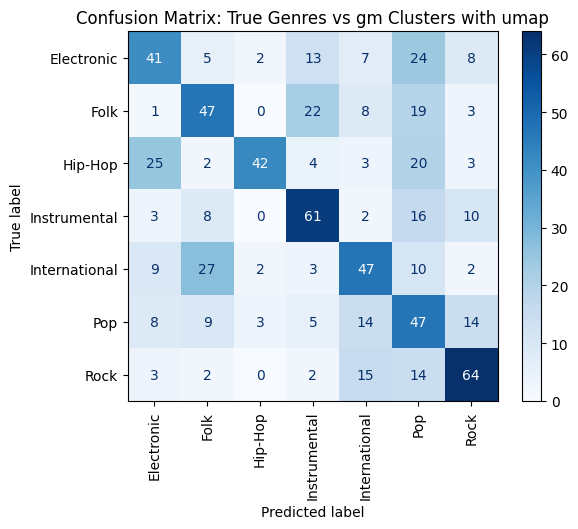

In [143]:
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from collections import Counter

# Create a dictionary to map clusters to the most frequent genre label in each cluster
cluster_to_label = {}
for cluster in range(kmeans.n_clusters):
    # Get the indices of the samples that belong to the current cluster
    cluster_indices = np.where(kmeans.labels_ == cluster)[0]
    
    # Get the true labels for those samples
    true_labels_for_cluster = true_labels_enc[cluster_indices]
    
    # Find the most frequent true label in the cluster
    most_common_label = Counter(true_labels_for_cluster).most_common(1)[0][0]
    
    # Map the cluster label to the most frequent true label
    cluster_to_label[cluster] = most_common_label

# Create predicted labels that align with true labels based on the cluster-to-label mapping
#aligned_predicted_labels = np.array([cluster_to_label[label] for label in kmeans.labels_])
mapping = greedy_cluster_mapping(true_labels_enc, predicted_labels)
aligned_predicted_labels = np.array([mapping[label] for label in predicted_labels])
# Create the confusion matrix
cm = confusion_matrix(true_labels_enc, aligned_predicted_labels)

# Create confusion matrix display
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)
disp.plot(xticks_rotation='vertical', cmap='Blues')

# Set the title and display the plot
plt.title(f"Confusion Matrix: True Genres vs {algorithm} Clusters with {reduction}")
plt.show()

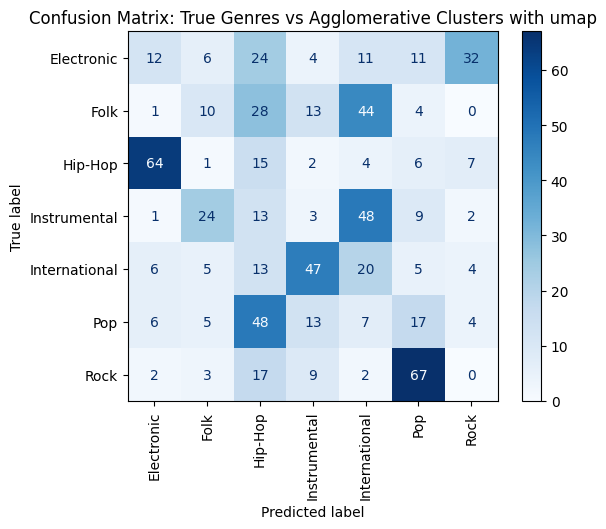

In [178]:
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from collections import Counter

# Create a dictionary to map clusters to the most frequent genre label in each cluster
cluster_to_label = {}
for cluster in range(kmeans.n_clusters):
    # Get the indices of the samples that belong to the current cluster
    cluster_indices = np.where(kmeans.labels_ == cluster)[0]
    
    # Get the true labels for those samples
    true_labels_for_cluster = true_labels_enc[cluster_indices]
    
    # Find the most frequent true label in the cluster
    most_common_label = Counter(true_labels_for_cluster).most_common(1)[0][0]
    
    # Map the cluster label to the most frequent true label
    cluster_to_label[cluster] = most_common_label

# Create predicted labels that align with true labels based on the cluster-to-label mapping
cm = confusion_matrix(true_labels_enc, kmeans.labels_)

# Solve assignment problem (maximizing matches)
mapping = greedy_cluster_mapping(true_labels_enc, predicted_labels)
aligned_predicted_labels = np.array([mapping[label] for label in predicted_labels])

# Create confusion matrix display
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)
disp.plot(xticks_rotation='vertical', cmap='Blues')

# Set the title and display the plot
plt.title(f"Confusion Matrix: True Genres vs {algorithm} Clusters with {reduction}")
plt.show()

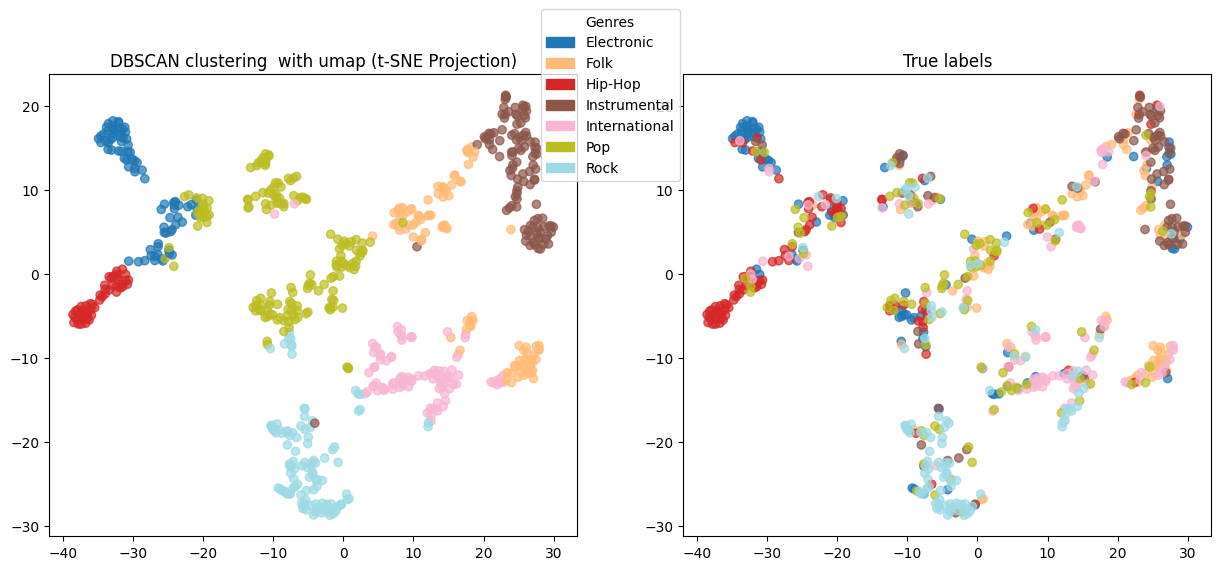

<Figure size 700x600 with 0 Axes>

In [139]:
from sklearn.manifold import TSNE
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt

unique_labels = np.unique(true_labels_enc)
cmap = "tab20"
label2genre = {enc: genre for enc, genre in zip(true_labels_enc, true_labels)}

# Make sure mapping is clean and non-redundant
label2genre = {enc: label2genre[enc] for enc in unique_labels}


X_2d = TSNE(n_components=2, random_state=42).fit_transform(spectrograms_reduced)
fig, axes = plt.subplots(1,2, figsize = (15,6))
plt.figure(figsize=(7, 6))
axes[0].scatter(X_2d[:, 0], X_2d[:, 1], c=aligned_predicted_labels, cmap=cmap, alpha=0.7)
axes[0].set_title(f"{algorithm} clustering  with {reduction} (t-SNE Projection)")
#plt.show()

#lt.figure(figsize=(6, 6))
#plt.scatter(X_2d[:, 0], X_2d[:, 1], c=true_labels_enc, cmap='tab10', alpha=0.7)
scatter = axes[1].scatter(X_2d[:, 0], X_2d[:, 1], c=true_labels_enc, cmap=cmap, alpha=0.7)
handles = [
    mpatches.Patch(color=scatter.cmap(scatter.norm(label)), label=label2genre[label])
    for label in unique_labels
]

fig.legend(handles=handles,  bbox_to_anchor=(0.1, 0.5, 0.45, 0.5), ncol=1, title="Genres")
plt.tight_layout()
axes[1].set_title(f"True labels")
plt.show()